mix them pixels yooo

In [3]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import isnan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import linear_mixing as lmx
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
import randomforest_CHAIN_working as rfcc

In [4]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [5]:
# Plotting settings and functions

plt.rcParams['font.family'] = 'serif' #sans-serif'

def calc_r2(true, predicted, note = ""):
    r2 = 1 - (np.sum((true - predicted)**2, axis = 0) / np.sum((true - np.mean(true, axis = 0))**2, axis = 0))
    print(f"R squared values for each component {note}:\n{r2}")
    return r2

def plot_multi_result(x_array, 
                      y_array, 
                      alpha, 
                      colour,
                      metric, 
                      cmap, 
                      fig_title, 
                      x_axis_label, 
                      y_axis_label, 
                      stats_values, 
                      line_1_1, 
                      sensor_code, 
                      class_code,
                      h_lines = None, 
                      save = False, 
                      output_dir = None,
                      output_name = None):
    fig, ax = plt.subplots(x_array.shape[1]//2 + x_array.shape[1]%2, 2, figsize = (8,8),) #sharex = True, sharey = True)
    fig.tight_layout(pad = 3)
    if isinstance(y_array, pd.DataFrame):
        y_array = y_array.values
    if isinstance(stats_values, pd.DataFrame):
        stats_values = stats_values.values

    for col in range(x_array.shape[1]):
        col_name = x_array.columns[col]
        ax[col//2, col%2].scatter(x_array[col_name], y_array[:,col], alpha = alpha, c = colour, cmap = cmap)
        ax[col//2, col%2].set_xlabel(f"{x_axis_label} of {col_name.replace("_", " ")}")
        ax[col//2, col%2].set_ylabel (y_axis_label)
        if stats_values is not None:
            ax[col//2, col%2].annotate(f"{metric} = {stats_values[metric][col]:.3f}", xy = (0.6, 0.1), xycoords = "axes fraction")
        if line_1_1:
            ax[col//2, col%2].axline((0,0), slope = 1, color = "black", linestyle = "--")
        if h_lines is not None:
            for h in h_lines:
                ax[col//2, col%2].axhline(y = h[0], color = h[1], linestyle = ":")
    if x_array.shape[1] % 2 == 1:
        ax[-1, -1].set_visible(False)  
    fig.suptitle(fig_title, y = 1)
    
    if save: 
        if not sensor_code or not class_code:
            ValueError("Sensor code and class code must be provided to save the figure.")
        if output_dir is None :
            output_dir = "./"
        
        os.makedirs(output_dir, exist_ok=True)
        filename = f"{sensor_code}_{class_code}_{output_name}.svg"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches = "tight")
    plt.show()

def calc_eval_stats(true_values, predicted):
    r2_list = []
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    all_stats = {}
    predicted = pd.DataFrame(predicted)
    true_values = pd.DataFrame(true_values)
    
    for i in range(true_values.shape[1]):
        r2 = r2_score(true_values.iloc[:, i], predicted.iloc[:, i])
        mse = mean_squared_error(true_values.iloc[:, i], predicted.iloc[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(true_values.iloc[:, i], predicted.iloc[:, i])
        # mape = np.mean(np.abs((true_values.iloc[:, i] - predicted.iloc[:, i]) / true_values.iloc[:, i]) * 100)
        # # den = true_values.iloc[:, 1]
        # mask = den != 0
        # mape = np.abs(den[mask] - predicted[mask, i])/den[mask] *100
        # mape = np.mean(mape)
        
        den = true_values.iloc[:, i].replace(0, np.nan)

        mape = np.nanmean(np.abs(true_values.iloc[:, i] - predicted.iloc[:, i]) / den * 100)

        
        
        # try: 
        #     mape = np.abs(true_values.iloc[:, i] - predicted[:, i]) / true_values.iloc[:, i]*100
        # except ZeroDivisionError:
        #     mape = np.nan
        # clean_mape = [x for x in mape if not isnan(x)]
        # mape = np.mean(clean_mape)
        
        
        r2_list.append(r2)
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        
    all_stats["R2"] = r2_list
    all_stats["MSE"] = mse_list
    all_stats["RMSE"] = rmse_list
    all_stats['MAE'] = mae_list
    all_stats['MAPE'] = mape_list
    
    return all_stats

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)

def fit_best_curve(x, y, mat, sensor_code, class_code, plot = True, criterion = "R2", colours= dict()):
     
    """Fit a set of lines to the data and decide on the best one based on R squared value.
        
    Args
        x (array-like): Independent variable data.
        y (array-like): Dependent variable data.
        mat (str) : Name of class being fitted.
        plot (bool): Whether to plot the best fit curve. Default is True.
        criterion (str): Criterion to evaluate the best fit. Default is "R2". Options are MAE, RMSE, MSE, MAPE, R2.
        
    Output
        best_fit_params (tuple): Parameters of the best fit curve.
        all_curve_params (dict): Parameters of all fitted curves.
        best_fit_line (str) : Type of curve that fits best
        all_stats (dict) : Evaluation stats of the fitted curves.
    """
    
    all_curve_params = {}
    
    colours = "teal" if None else colours

    # Fit sigmoid curve    
    p0 = [max(y), np.mean(x), 1, 0] # mandatory initial guess
    popt, _ = curve_fit(sigmoid, x, y, p0, method='trf')
    x_linspace = np.linspace(np.min(x), np.max(x), 500)
    y_fitted_sigmoid = sigmoid(x_linspace, *popt)
    y_pred_sigmoid = sigmoid(x, *popt)
    all_curve_params = {'sigmoid': popt}

    sigmoid_stats = calc_eval_stats(y, y_pred_sigmoid)
    all_stats = {'sigmoid' : sigmoid_stats}
    
    # Fit straight line
    b, m = np.polyfit(x, y, 1)
    all_curve_params["linear"] = (b, m)
    y_fitted_linear = b*x_linspace + m
    y_pred_linear = b*x +m

    linear_stats = calc_eval_stats(y, y_pred_linear)
    all_stats['linear'] = linear_stats
    
    # Pick best curve
    if criterion == "R2":
        sigmoid_r2 = sigmoid_stats['R2'][0]
        linear_r2 = linear_stats['R2'][0]
        if sigmoid_r2 > linear_r2:
            best_fit_line = "sigmoid"
            best_fit_params = popt
        else:
            best_fit_line = "linear"
            best_fit_params = (m, b)
    elif criterion == "MAE":
        sigmoid_mae = sigmoid_stats['MAE'][0]
        linear_mae = linear_stats['MAE'][0]
        if sigmoid_mae < linear_mae:
            best_fit_line = "sigmoid"
            best_fit_params = popt
        else:
            best_fit_line = "linear"
            best_fit_params = (m, b)
    
    # Optional plotting
    if plot: 
        ax = plt.axes()
        ax.scatter(x, y, color = colours, alpha = 0.5,)
        ax.plot(x_linspace, y_fitted_sigmoid, '--', color = "red", label='Fitted curve - Sigmoid')
        ax.plot(x_linspace, y_fitted_linear, '--', color = "gold", label='Fitted curve - Linear')
        ax.axline((0,0), slope = 1, color = "black", linestyle = "dotted", label = "1:1 line")
        ax.set_title(f'Fitting curves to fit {mat} prediction data')
        ax.set_ylabel(f'Predicted {mat} probability')
        ax.set_ylim(0, 1)
        ax.set_xlabel(f'{mat} fractional cover')
        ax.annotate(f" Best fit: {best_fit_line.capitalize()} \n {criterion}: {all_stats[best_fit_line][criterion][0]:.4f}", xy = (0.6, 0.15), xycoords = "axes fraction", fontsize = 10,)
        ax.legend()
        plt.savefig(f"plots/regression/evaluation/{sensor_code}_{class_code}_{mat}_best_fit_curve_{criterion}.svg")
        plt.show()
    
    return best_fit_params, all_curve_params, best_fit_line, all_stats

def invert_predicted_values(predicted_values, y_test, fitted_curves):
    """ 
    Invert the best fitted curves to back-calculate the expected/adjusted FPC values for any given regression output.
    
    """
    predicted_covers = pd.DataFrame(index = y_test.index, columns = y_test.columns)
    for col in range(y_test.shape[1]):
        class_name = y_test.columns[col]
        
        if len(fitted_curves[class_name]) == 4:
            # Access sigmoid params
            L, x0, k, b = fitted_curves[class_name]
            # values = np.array([x if x > b else b for x in predicted_values[:,col] ])
            # Calculate inverse sigmoid for predicted values
            x_result = inverse_sigmoid(predicted_values[:, col], L, x0, k, b)
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[class_name] = x_result
            
        elif len(fitted_curves[class_name]) == 2:
            # Access linear params
            b, m = fitted_curves[class_name]
            # Calculate inverse linear for predicted values
            x_result = (predicted_values[:, col] - b) / m
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[class_name] = x_result
            
    return predicted_covers

def inverse_sigmoid(y, L, x0, k, b):
    """
    Inverse of sigmoid function.
    Given y, returns x.
    """
    
    y = np.array(y, dtype = float)
    
    # Check if y is in valid range
    if np.any((y - b) <= 0) or np.any((y - b) >= L):
        print("Warning: y values outside valid range (b < y < L+b)")
        
    bad = (y - b <= 0) | (y - b >= L)
    if np.any(bad):
        print("Adjusting bad y values:", y[bad])
        
    # Small epsilon to avoid log(0) or negative arguments
    eps = 1e-12

    # Compute the valid range for y
    y_min = b + eps
    y_max = L + b - eps

    # Clip y to the range
    y = np.clip(y, y_min, y_max)
        
    x = x0 - (1/k) * np.log(L/(y - b) - 1)

    return x

def plot_mixpix_components(pixel_fpcs, colours,  sensor_code, class_code, save = False, output_dir = None):
    """ 
    Plot the fractional percent cover distributions of the simulated pixels.
    
    """
    if pixel_fpcs.empty:
        ValueError("No valid pixel fractional percent cover data to plot.")
    
    fpcs = pixel_fpcs.copy()
    fpcs["count"] = fpcs.astype(bool).sum(axis=1)

    mat_count = fpcs.shape[1]
    fig, ax = plt.subplots(mat_count//2 + mat_count%2, 2, figsize = (8,6))
    fig.tight_layout(pad = 3)

    for col in range(mat_count):
        ax[col//2, col%2].hist(fpcs.iloc[:,col], 
                               bins = 50, 
                               range = (0, max(fpcs.iloc[:, col])), 
                               color = colours.get(fpcs.columns[col], "navy"), log = True)
        annotation = fpcs.columns[col].replace("_", " ").capitalize()
        ax[col//2, col%2].annotate(annotation,  
                                   xy = (0.2, 0.8), 
                                   xycoords = "axes fraction")
        
        if fpcs.columns[col] != "count":
            ax[col//2, col%2].set_xlabel("Fractional Cover")
        else:
            ax[col//2, col%2].set_xlabel("Number of Classes Simulated")
            
        ax[col//2, col%2].set_ylabel("Pixel Count")

    if mat_count % 2 == 1:
        ax[-1, -1].set_visible(False)
    fig.suptitle("Distribution of Simulated Fractional Covers", y = 1.02)
    if save: 
        if not sensor_code or not class_code:
            ValueError("Sensor code and class code must be provided to save the figure.")
        if output_dir is None :
            output_dir = "./"
        
        os.makedirs(output_dir, exist_ok=True)
        filename = f"{sensor_code}_{class_code}_mixpix_comps_dist.svg"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches = "tight")
    plt.show()

In [6]:
# Set persistent notebook parameters
colours = {
    "kelp": "gold",
    "brown_algae": "sienna" ,
    "red_veg": "tomato",
    "green_veg": "green",
    "mineral" : "grey",
    "water" : "teal",
}
sensor_code = "Enmap"
class_code = "kbrgm"
plot_output_dir = "C:/Users/s4770224/Documents/Work/Writing/Figures/Obj1/part2/"


# mixing pixels

In [7]:
material_options = {
    # "kelp" : ['ecklonia', 'macrocystis', 'undaria'],
    # "brown_non_kelp" : ['acrocarpia', 'cystophora', 'carpophyllum', 
    #                 'durvillaea', 'hormosira', 'petalonia','phyllospora', 'sargassum', 'scytosiphon'],
    "brown_algae" : ['ecklonia', 'macrocystis', 'petalonia', 
                     'undaria','acrocarpia', 'cystophora', 'carpophyllum', 'durvillaea', 'hormosira', 'phyllospora', 'sargassum', 'scytosiphon'],
    "red_veg" : ['frondose_rhodophyte','filamentous_rhodophyte'], 
    "green_veg" : ["ulva"], #['grass', 'ulva'],
    # "non_brown_autos" : ['grass', 'filamentous_rhodophyte',
    #                      'frondose_rhodophyte', 'rhodophyte', 'ulva'],
    # "all_non_kelp_autos" : ['acrocarpia', 'carpophyllum', 'cystophora', 
    #                         'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'petalonia', 'grass','hormosira','phyllospora', 'rhodophyte',  'sargassum','scytosiphon','ulva'],
    # "all_non_kelp" : ['acrocarpia', 'barnacle_shells', 'carpophyllum',
    #                   'cystophora', 'durvillaea', 'filamentous_rhodophyte','frondose_rhodophyte', 'gravel', 'grass','hormosira','mussels','petalonia','phyllospora', 'rhodophyte', 'rock','sand', 'sargassum', 'scytosiphon', 'shell_litter','rock', 'ulva', 'worm_castings'],
    "mineral" : ['barnacle_shells', 'gravel', 'mussels', 'rock', 'sand', 
                  'shell_litter', 'worm_castings'],
    }

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {material_options.keys()} " )

Classes to be simulated : dict_keys(['brown_algae', 'red_veg', 'green_veg', 'mineral']) 


In [8]:
# #Assign fractional cover ranges with simulate within

cover_ranges = {
    # "kelp" : (0,1),
    # "brown_non_kelp" : (0,1),
    "brown_algae" : (0, 1),
    "red_veg" : (0,1),
    "green_veg" : (0, 1),
    #"non_brown_autos" : (0, 40),
    #"all_non_kelp_autos" : (0, 100),
    #"all_non_kelp" : (0,100),
    "mineral" : (0, 1),}

presence_odds = {
    # "kelp" : (0,1),
    # "brown_non_kelp" : (0,1),
    "brown_algae" : (1, 0),
    "red_veg" : (1, 0),
    "green_veg" : (1, 0),
    #"non_brown_autos" : (0, 40),
    #"all_non_kelp_autos" : (0, 100),
    #"all_non_kelp" : (0,100),
    "mineral" : (1, 0),}

In [9]:
# Load spectral data from file and prep
data = pd.read_csv("./data/processed/resampled/noisy_Enmap_resampled.csv", index_col=0)
labels = pd.read_csv("data/labels_prepped.csv", index_col=0)
data = pd.concat([labels["Class"], data], axis = 1)
data = data [data["Class"].isin(all_allowed)]
labels = labels[labels["Class"].isin(all_allowed)]

In [14]:
# Load and prepare water pixel spectra from file

water_spec = pd.read_csv("./Enmap_pixel_samples.csv")
water_spec.head()

# get rid of bands outside of endmember spectral range
water_spec = water_spec.iloc[:, 8:86] 

# De-duplicate water spectra
water_spec.drop_duplicates(inplace = True)
# water_meta = water_meta.loc[water_spec.index]
print(f"Total of {water_spec.shape[0]} unique water pixels")

# Remove bad data from QGIS export
a = water_spec.values
b = (a == a[[0], :]).all(axis=0)
c = (a == a[:, [0]]).all(axis=1)

water_spec = water_spec.loc[c==0, b==0]
water_meta = water_spec.index.to_frame()

water_spec.shape
water_spec = water_spec/10000  # Convert to reflectance

Total of 100000 unique water pixels


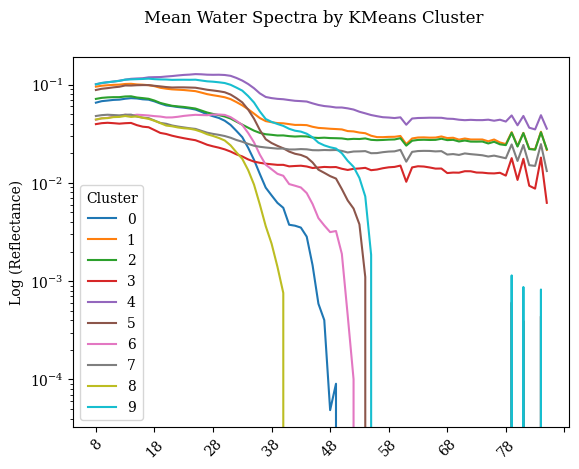

In [15]:
# Examine the water spectra being used

clusters = KMeans(n_clusters = 10, n_init ='auto').fit(water_spec)
water_meta["cluster"] = clusters.labels_
water_spec.groupby(water_meta["cluster"]).mean().T.plot()
plt.xticks(rotation = 45)
plt.suptitle("Mean Water Spectra by KMeans Cluster")
plt.ylabel("Log (Reflectance)")
plt.yscale("log")
plt.legend(title = "Cluster", loc = "best")
plt.show()

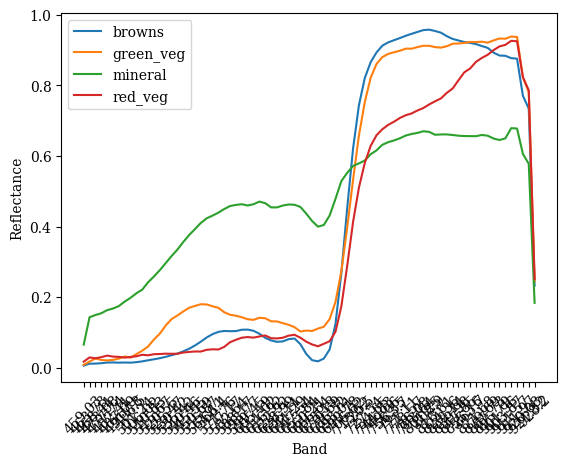

In [16]:
# Plot mean endmember spectra 
labels["brgm"] = labels["kbrgm"].replace(to_replace=["kelp", "other_brown_alg"], value = "browns")
endmembers = pd.DataFrame(data.iloc[:, 1:]).groupby(labels["brgm"]).mean()

plt.plot(endmembers.T)
plt.legend(endmembers.index)
plt.xticks(rotation = 45)
plt.ylabel("Reflectance")
plt.xlabel("Band")  
plt.show()

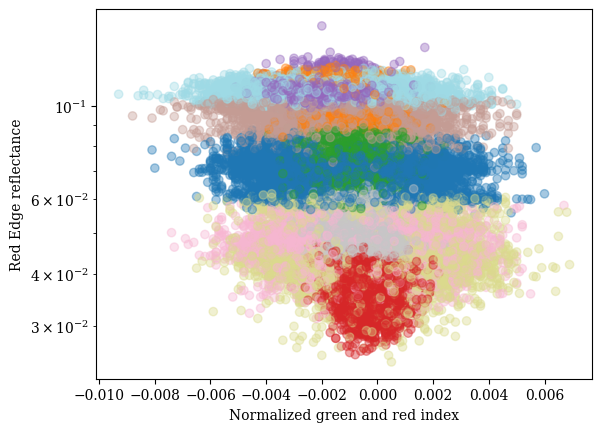

In [17]:
#plot kmeans clusters
plt.scatter((water_spec.iloc[:, 1]-water_spec.iloc[:, 2]), water_spec.iloc[:, 3], c = water_meta["cluster"], cmap = "tab20", alpha = 0.4)
plt.yscale("log")
plt.ylabel("Red Edge reflectance")
plt.xlabel( "Normalized green and red index")
plt.show()

In [18]:
# Split spectra into training and testing sets
data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size = 0.3, stratify=labels["kbrgm"])

water_train, water_test = train_test_split(water_spec, test_size = 0.3)
water_meta_train = water_meta.loc[water_train.index]
water_meta_test = water_meta.loc[water_test.index]

In [19]:
# Instantiate the pixel mixer
mixer = lmx.LinearMixing(materials = material_options, 
                         cover_ranges = cover_ranges, 
                         pixels = 10000,
                         odds_dict = presence_odds,
                         material_spectra= data_train, 
                         water_spectra = water_train)

# Mix pixels and store results
results, f, endmember_indices = mixer.sim_many_pixels()

# Format results and clear old variables
sim_pix, fpcs, endmember_indices = mixer.format_sim_results(results, f, endmember_indices)
del results, f

# Inspect simulated results
print(f"{sim_pix.shape[0]} simulated pixels with {sim_pix.shape[1]} spectral bands \n")
print(f"Preview of simulated component fractional covers: \n {fpcs.head()}")


10000 simulated pixels with 78 spectral bands 

Preview of simulated component fractional covers: 
    brown_algae   red_veg  green_veg   mineral     water
0     0.000000  0.000000   0.150585  0.825365  0.024049
1     0.000000  0.000000   0.000000  0.000000  1.000000
2     0.062862  0.427105   0.062388  0.445651  0.001993
3     0.496638  0.000000   0.374605  0.000000  0.128757
4     0.000000  0.523733   0.000000  0.000000  0.476267


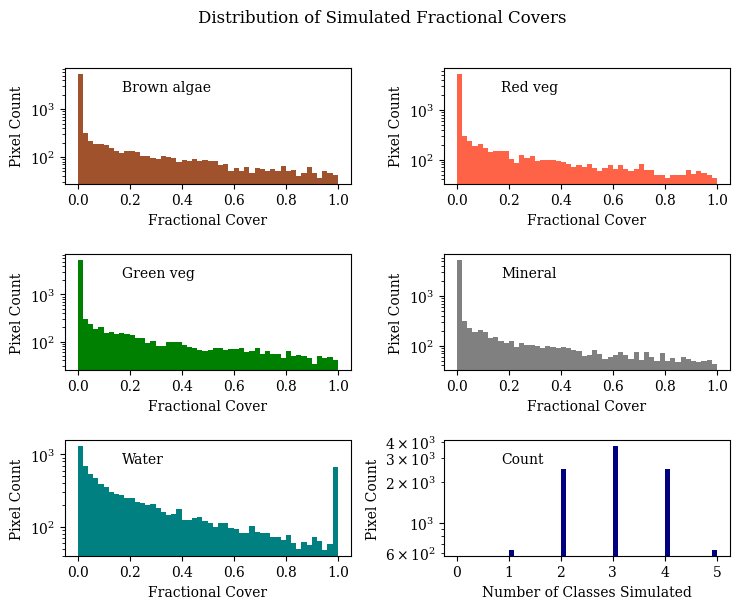

In [20]:
# Plot the components of the simulated pixels      
plot_mixpix_components(fpcs, colours, sensor_code= sensor_code, class_code = class_code, save = True, output_dir = plot_output_dir)

In [21]:
# Export simulated pixels

#simulated_pixels.to_csv(f"data/mixed_sims/{sensor_code}_{class_code}_mixpix.csv")
#fpcs.to_csv(f"data/mixed_sims/{sensor_code}_{class_code}_fpcs.csv)

# Prepare data for classification

In [22]:
# Define what you simulated
label_level = "kbrgm"
keep_list = ["kelp", "water", "other_brown_alg", "mineral", "green_veg", "red_veg"]

# Add water to classifier training set 
sample_idx = np.random.choice(water_train.index, size = 1000, replace = False)
water_labels = pd.DataFrame("water", index = sample_idx, columns = labels.columns)
water_sample = water_train.loc[sample_idx, :]
water_sample.columns = data_train.columns[1:]
data_watered = pd.concat([data_train, water_sample], axis = 0)
labels_watered = pd.concat([labels_train, water_labels], axis = 0).set_index(data_watered.index)
data_watered = pd.concat([labels_watered, data_watered.iloc[:, 1:]], axis = 1)

# Combine kelp and other phaeophytes into single "browns" class
labels_watered["brgm"] = labels_watered["kbrgm"].replace(to_replace=["kelp", "brown_non_kelp"], value = "browns")

# Filter training data to only mixed pixel components
data_watered = data_watered[data_watered[label_level].isin(keep_list)]
water_endmember = data_watered[label_level] == "water"

In [53]:
# Extract PCA components and transform dataset
deco = PCA(min(sim_pix.shape[1], 15))
deco.fit(sim_pix) #.iloc[:,8:]) #ENDMEMBERS?
# decomposed_endmembers = deco.transform(data_watered.iloc[:, 8:])
decomposed_mixpix = deco.transform(sim_pix)
comps = deco.components_

# Perform presence Absence classification

In [58]:
# divide the dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(decomposed_mixpix, fpcs, train_size = 0.5, random_state = 7)
x_train = pd.DataFrame(x_train, index= y_train.index)
x_test = pd.DataFrame(x_test, index = y_test.index)

In [59]:
# grid search
# parameter_grid_r = {
#     'max_depth': [5, 10, 15],
#     'max_samples': [0.6, 0.8],
#     'min_samples_leaf': [5, 10],
#     'min_samples_split': [10, 20],
#     }

# grid_rf = GridSearchCV(estimator = rf,
#                        param_grid = parameter_grid_r,
#                        scoring = 'r2',
#                        cv = 3,
#                        n_jobs = -1,
#                        verbose = 2)
# grid_rf.fit(x_train, y_train)

In [60]:
# best_model = grid_rf.best_estimator_
# test_acc = best_model.score(x_test, y_test)
# print(f"best modelt est score is : {test_acc}")
# best_model.get_params()

# # {'bootstrap': True,
# #  'ccp_alpha': 0.0,
# #  'criterion': 'absolute_error',
# #  'max_depth': 15,
# #  'max_features': 'sqrt',
# #  'max_leaf_nodes': None,
# #  'max_samples': 0.6,
# #  'min_impurity_decrease': 0.0,
# #  'min_samples_leaf': 5,
# #  'min_samples_split': 10,
# #  'min_weight_fraction_leaf': 0.0,
# #  'monotonic_cst': None,
# #  'n_estimators': 100,
# #  'n_jobs': -1,
# #  'oob_score': True,
# #  'random_state': 123,
# #  'verbose': 1,
# #  'warm_start': False}

In [61]:
# grid_predict = best_model.predict(x_test)
# grid_predict[:10,:]

In [62]:
classifier_params = {
    "n_estimators": 200,
    "max_depth": 25,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
}

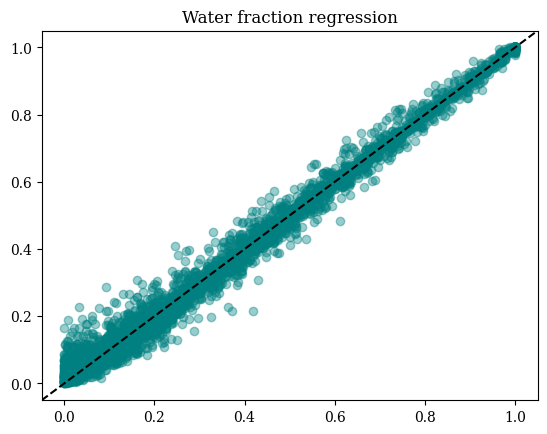

Classification test score: 0.833
Not plotting brown_algae classifier...
Classification test score: 0.8256
Not plotting red_veg classifier...
Classification test score: 0.8438
Not plotting green_veg classifier...
Classification test score: 0.864
Not plotting mineral classifier...


In [63]:
pipe = rfcc.Unmix_Pixels(x_train, y_train, x_test, y_test, presence_absence_thresh= 0.2)
presence_probas = pipe.classify_and_append(classifier_params, plot = "water")

In [64]:
# Store classifications and water reg results
train_classifications = pd.DataFrame({k : v for k, v in presence_probas["train"].items()})
test_classifications = pd.DataFrame({k : v for k, v in presence_probas["test"].items()})


C:\Users\s4770224\AppData\Local\Temp\ipykernel_2504\3180214622.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[col//2, col%2].scatter(x_array[col_name], y_array[:,col], alpha = alpha, c = colour, cmap = cmap)


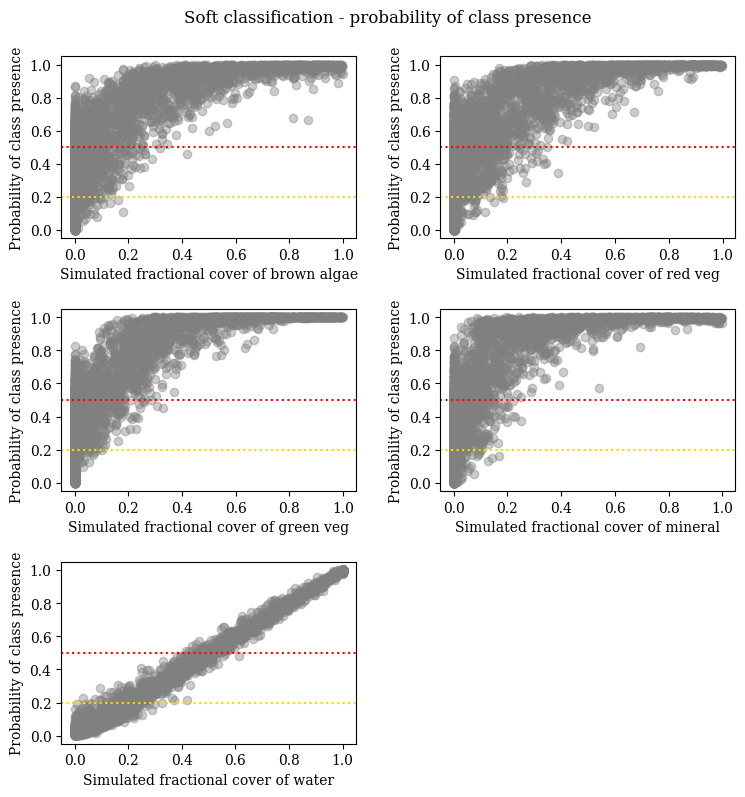

In [65]:
# Plot soft classification results
plotting_params = {
    "x_array": y_test, 
    "y_array": test_classifications, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour": "grey", #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Soft classification - probability of class presence",
    "x_axis_label": "Simulated fractional cover",
    "y_axis_label" : "Probability of class presence", 
    "stats_values" : None,
    "line_1_1" : False, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "h_lines" : [(0.2, "gold"), (0.5, "red")],
    "save" : True,
    "output_dir" : plot_output_dir,
    "output_name" : "rf_chain_soft_classification_testset"
}

plot_multi_result(**plotting_params)  

In [106]:
# regressor_params = { #best_model.get_params()
#     "n_estimators": 500,
#     "max_depth": 5,
#     "min_samples_split": 100,
#     "min_samples_leaf": 5,
#     "max_features" : 10,
#     "random_state": 42,
# }
regressor_params = {
    'bootstrap': True,
    'ccp_alpha': 0.0,
    'criterion': 'absolute_error',
    'max_depth': 15,
    'max_features': "sqrt",
    'max_leaf_nodes': None,
    'max_samples': 0.5,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 2,
    'min_samples_split': 5,
    'min_weight_fraction_leaf': 0.0,
    'monotonic_cst': None,
    'n_estimators': 100,
    'n_jobs': -1,
    'oob_score': True,
    'random_state': 123,
    'verbose': 0,
    'warm_start': False,  
}

In [107]:
regressor_predictions = pipe.filter_and_regress(plot = "none", regressor_params= regressor_params)

brown_algae present in 3758 out of 5000 test pixels
Training set for brown_algae has 5000 samples
Not plotting brown_algae regression...
red_veg present in 3904 out of 5000 test pixels
Training set for red_veg has 5000 samples
Not plotting red_veg regression...
green_veg present in 4011 out of 5000 test pixels
Training set for green_veg has 5000 samples
Not plotting green_veg regression...
mineral present in 3515 out of 5000 test pixels
Training set for mineral has 5000 samples
Not plotting mineral regression...


In [108]:
# Store regression results
train_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in regressor_predictions["train"].items()})
test_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in regressor_predictions["test"].items()})

# Combine regression results and classifications based on presence threshold
overall_train_results = pd.DataFrame(index = train_classifications.index, columns= train_classifications.columns)
for col in train_regressions.columns:
    for row in train_regressions.index:
        if train_classifications.loc[row, col] > 0.2:
            overall_train_results.loc[row, col] = train_regressions.loc[row, col]
        else:
            overall_train_results.loc[row, col] = 0
overall_train_results["water"] = train_classifications["water"]

overall_test_results = pd.DataFrame(index = test_classifications.index, columns= test_classifications.columns)
for col in test_regressions.columns:
    for row in test_regressions.index:
        if test_classifications.loc[row, col] > 0.2:
            overall_test_results.loc[row, col] = test_regressions.loc[row, col]
        else:
            overall_test_results.loc[row, col] = 0
overall_test_results["water"] = test_classifications["water"]

# Adjust for unity
overall_test_area_adjusted = overall_test_results.div(overall_test_results.sum(axis = 1), axis = 0)

overall_train_results.replace(np.nan, 0, inplace = True)
overall_test_results.replace(np.nan, 0, inplace = True)
overall_test_area_adjusted.replace(np.nan, 0, inplace = True)

# Calculate evaluation stats
overall_train_stats = calc_eval_stats(y_train, overall_train_results)
overall_test_stats = calc_eval_stats(y_test, overall_test_results)
area_adjusted_stats = calc_eval_stats(y_test, overall_test_area_adjusted)

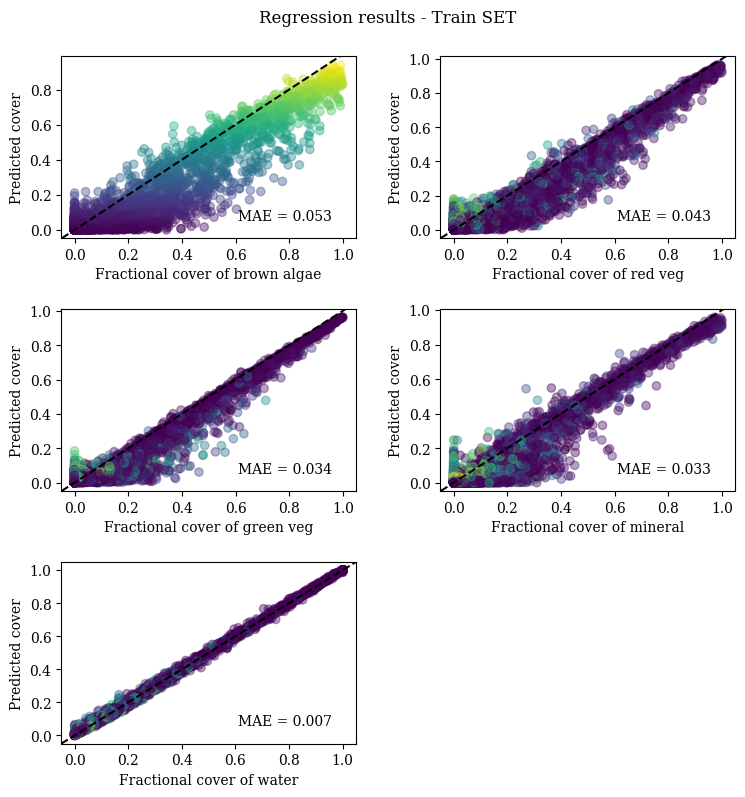

In [109]:
# Plot regressor results

plotting_params = {
    "x_array": y_train, 
    "y_array": overall_train_results, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":overall_train_results.iloc[:, 0], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Regression results - Train SET",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : overall_train_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_water_fpc"
}

plot_multi_result(**plotting_params)  

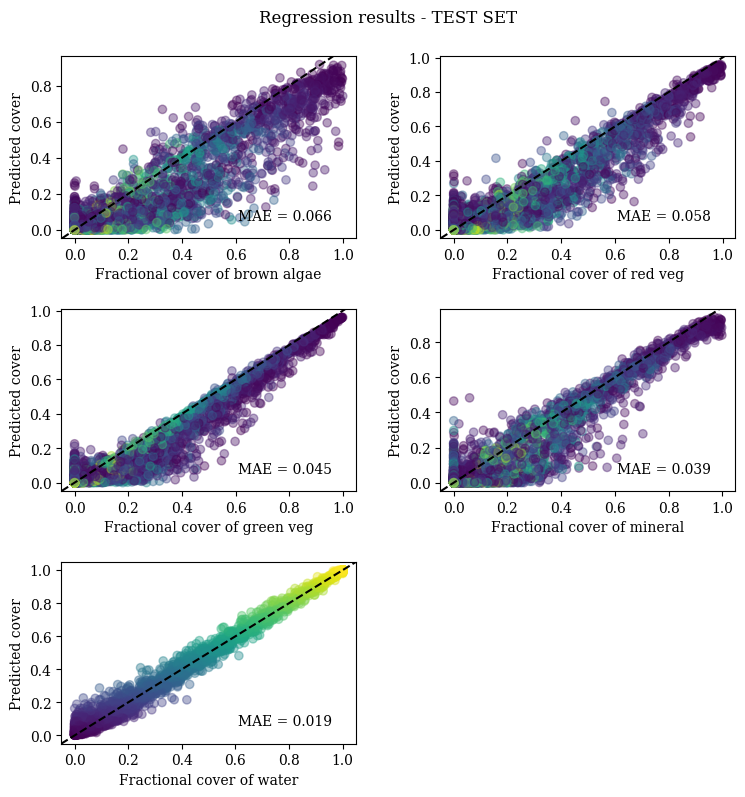

In [110]:
# Plot regressor results

plotting_params = {
    "x_array": y_test, 
    "y_array": overall_test_results, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":overall_test_results.iloc[:, -1], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Regression results - TEST SET",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : overall_test_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_water_fpc"
}

plot_multi_result(**plotting_params)  

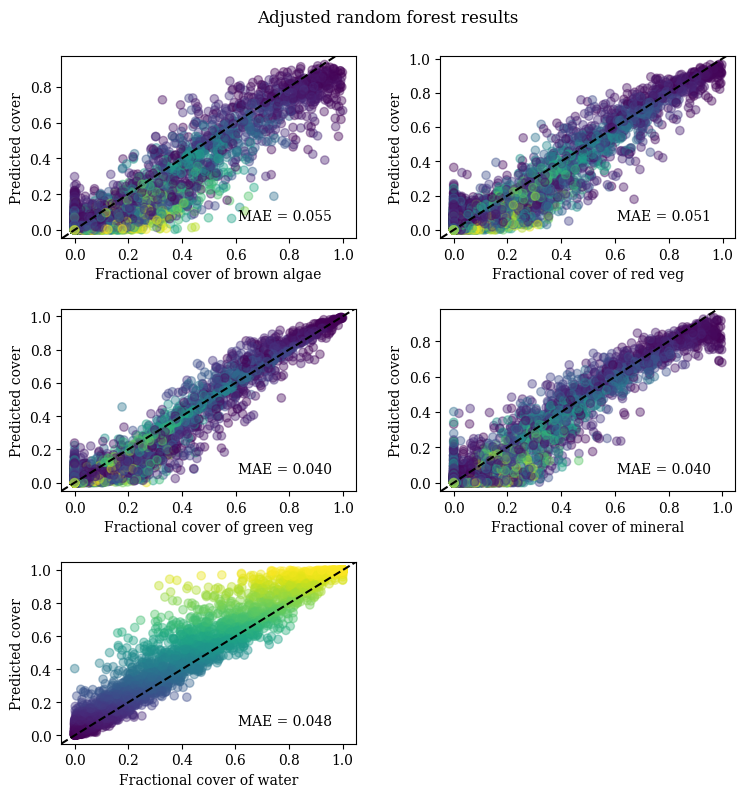

In [111]:
# Plot adjusted regressor results

plotting_params = {
    "x_array": y_test, 
    "y_array": overall_test_area_adjusted, 
    "alpha": 0.4, # p[:,-1],
    "metric" : "MAE", 
    "colour":overall_test_area_adjusted.iloc[:, -1], #p[:,-1],
    "cmap" : "viridis", 
    "fig_title" : "Adjusted random forest results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : area_adjusted_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_test_adjusted_water_fpc"
}

plot_multi_result(**plotting_params)  

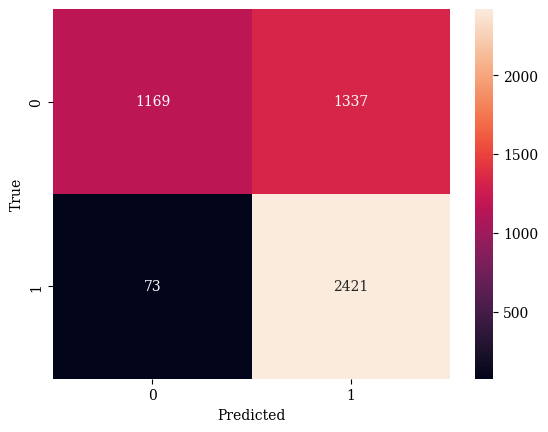

In [112]:
i = 0
sns.heatmap(confusion_matrix(y_test.iloc[:, i]>0, test_classifications.iloc[:, i]>0.2), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Trying just regression and inversion

In [113]:
rfr = RandomForestRegressor(**regressor_params)
rfr.fit(x_train, y_train)
train_pred = rfr.predict(x_train)
test_pred = rfr.predict(x_test)


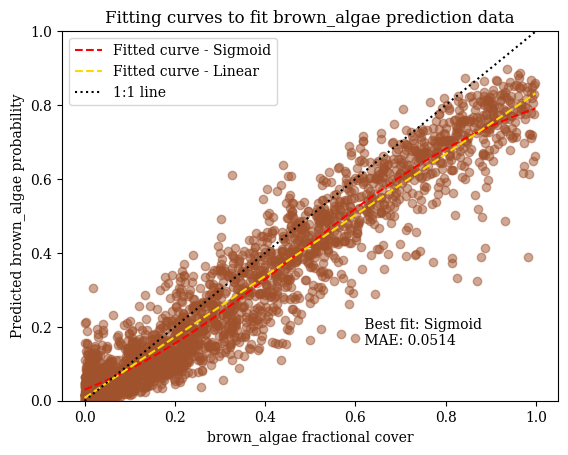

Best fit curve is a Sigmoid for brown_algae with parameters [ 1.04968356  0.4714946   3.68339698 -0.12702425]


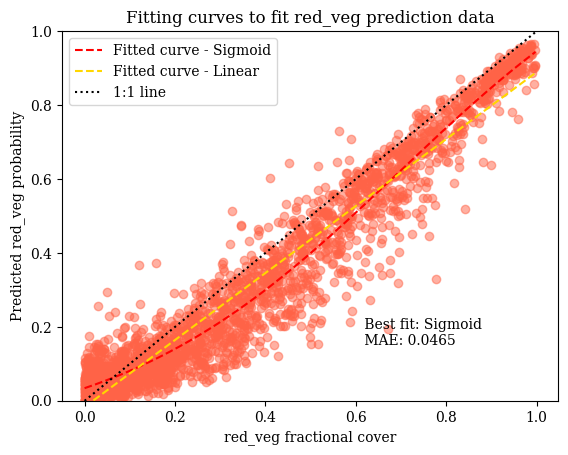

Best fit curve is a Sigmoid for red_veg with parameters [ 1.4620631   0.69692516  3.16534316 -0.11076189]


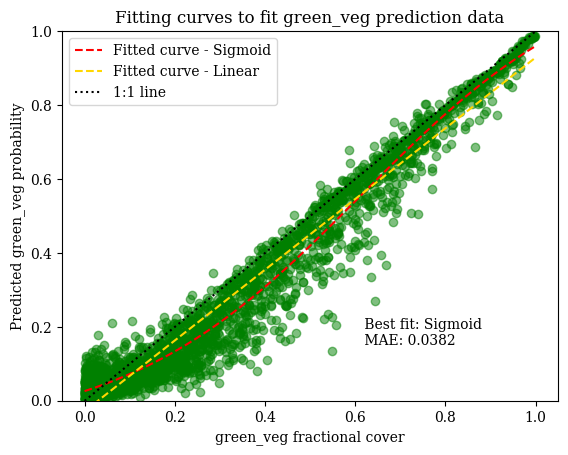

Best fit curve is a Sigmoid for green_veg with parameters [ 1.28720052  0.61336607  3.80880233 -0.08713621]


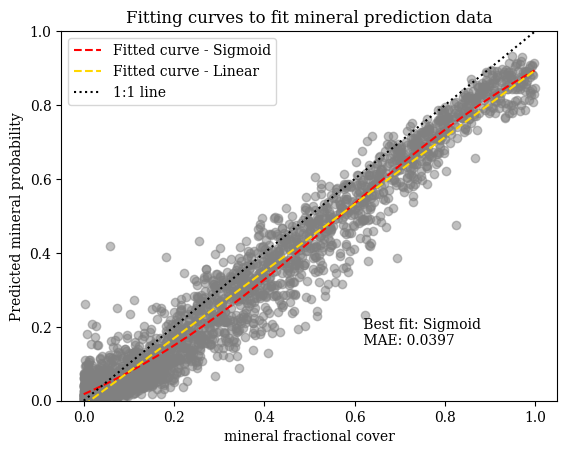

Best fit curve is a Sigmoid for mineral with parameters [ 1.36728488  0.5616382   3.06644219 -0.18969284]


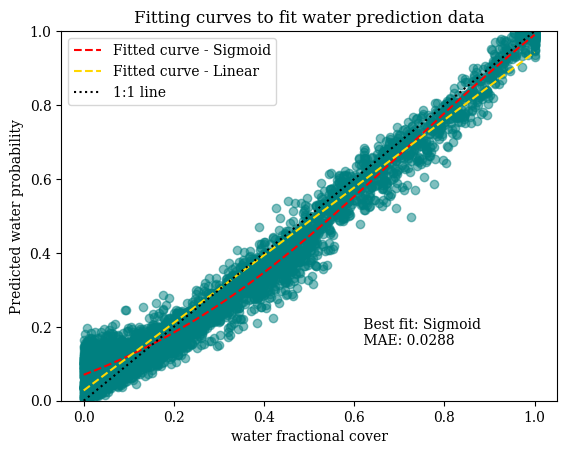

Best fit curve is a Sigmoid for water with parameters [ 1.60307567  0.71965297  2.83518229 -0.11423416]


In [114]:
fitted_curves = {}
curve_stats = {}
for col in range(y_test.shape[1]):
    y_non_zero = y_test[y_test.iloc[:, col] > 0 ]
    p_non_zero = test_pred[y_test.iloc[:,col] >0]
    colour = colours.get(y_test.columns[col], "magenta")
    best_fit_params, all_curve_params, best_fit_line, all_stats = fit_best_curve(
        y_non_zero.iloc[:, col], 
        p_non_zero[:, col], 
        y_non_zero.columns[col], 
        plot = True, 
        criterion = "MAE", 
        colours = colour, 
        sensor_code = sensor_code, 
        class_code = class_code)
    print(f"Best fit curve is a {best_fit_line.capitalize()} for {y_test.columns[col]} with parameters {best_fit_params}")
    fitted_curves[y_test.columns[col]] = best_fit_params
    curve_stats[y_test.columns[col]] = all_stats
    
del y_non_zero, p_non_zero


In [115]:
# Invert and adjust for totality
adjusted_predicted = invert_predicted_values(test_pred, y_test, fitted_curves)
area_adjusted = adjusted_predicted.div(adjusted_predicted.sum(axis = 1), axis = 0)
adj_stats = calc_eval_stats(y_test, area_adjusted)

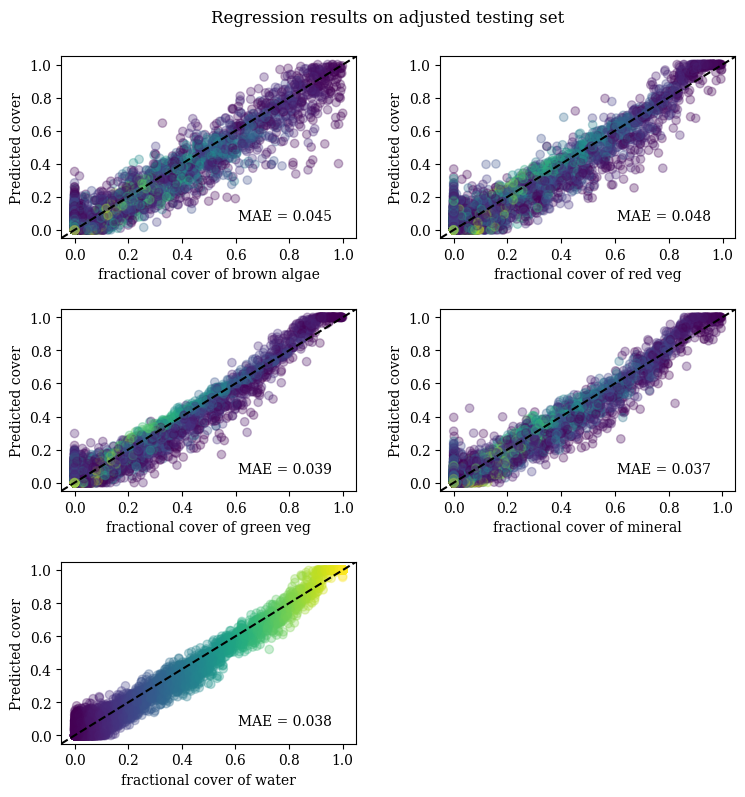

In [116]:

plotting_params = {
    "x_array": y_test, 
    "y_array": area_adjusted, 
    "alpha": 0.3, #y_test.iloc[:,-1],
    "colour": y_test.iloc[:,-1],
    "metric" : "MAE",
    "cmap" : "viridis", 
    "fig_title" : "Regression results on adjusted testing set",
    "x_axis_label": "fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : adj_stats, 
    "line_1_1" : True,
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : False,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "adj_reg_test_water_fpc"
}
plot_multi_result(**plotting_params)

# Run Chained classification-regression on new data

In [117]:
# Instantiate the pixel mixer
mixer = lmx.LinearMixing(materials = material_options, 
                         cover_ranges = cover_ranges, 
                         pixels = 10000, 
                         material_spectra= data_test,
                         odds_dict= presence_odds, 
                         water_spectra = water_test)

# Mix pixels and store results
new_results, new_f, new_endmember_indices = mixer.sim_many_pixels()

# Format results and clear old variables
new_mixpix, new_pixel_fpcs, new_endmembers = mixer.format_sim_results(new_results, new_f, new_endmember_indices)
del new_results, new_f, new_endmember_indices


# Inspect simulated results
print(f"{new_mixpix.shape[0]} pixels simulated with {new_mixpix.shape[1]} spectral bands \n")
print(new_pixel_fpcs.head())

10000 pixels simulated with 78 spectral bands 

   brown_algae   red_veg  green_veg   mineral     water
0     0.000000  0.536062   0.432238  0.000000  0.031700
1     0.000000  0.371749   0.512999  0.038683  0.076569
2     0.031819  0.000000   0.000000  0.000000  0.968181
3     0.000000  0.523604   0.000000  0.000000  0.476396
4     0.000000  0.814097   0.000000  0.000000  0.185903


In [118]:
deco_new_mixpix = pd.DataFrame(deco.transform(new_mixpix))

In [119]:
pipe.x_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,100,101,102,103,104
3655,1.727415,-0.118038,-0.115217,-0.034247,0.096592,0.076944,0.015151,0.061700,-0.023320,-0.023284,0.005151,-0.033791,-0.009477,-0.002344,-0.013617,0.016877,True,True,False,True
9587,1.400997,-0.138829,-0.119405,-0.041918,0.120284,0.089708,0.004983,0.075307,-0.032136,-0.013068,0.013614,-0.038277,-0.008636,-0.000239,-0.014039,0.083438,False,True,True,False
3226,1.624976,-0.425658,-0.334658,0.043690,0.112079,0.107255,0.044934,0.050668,0.035357,-0.010858,0.011581,-0.041646,-0.002638,-0.006213,0.019171,0.073520,True,True,False,False
1244,0.952815,0.025565,-0.000444,-0.034034,-0.027714,-0.066396,-0.069189,-0.017270,-0.020443,0.006123,0.009609,0.001945,-0.014197,0.000151,0.006265,0.188071,False,False,True,False
2581,0.832147,-0.308980,-0.366323,0.056238,0.053216,-0.098075,0.094274,-0.039462,-0.009725,0.017304,-0.019758,0.007134,0.010288,0.012679,-0.004265,0.201054,True,False,True,True


In [120]:
new_pixel_classifications, new_pixel_regressions = pipe.unmix_new_data(deco_new_mixpix, pd.DataFrame(new_pixel_fpcs))

In [121]:
new_pixel_classifications = pd.DataFrame({k : v.iloc[:,0] for k, v in new_pixel_classifications.items()})
new_pixel_regressions = pd.DataFrame({k : v.iloc[:, 0] for k, v in new_pixel_regressions.items()})

In [122]:
new_overall_test_results = pd.DataFrame(index = new_pixel_classifications.index, columns= new_pixel_classifications.columns)
for col in new_pixel_regressions.columns:
    for row in new_pixel_regressions.index:
        if new_pixel_classifications.loc[row, col] > 0.2:
            new_overall_test_results.loc[row, col] = new_pixel_regressions.loc[row, col]
        else:
            new_overall_test_results.loc[row, col] = 0
new_overall_test_results["water"] = new_pixel_classifications["water"]

In [123]:
new_stats = calc_eval_stats(new_pixel_fpcs, new_overall_test_results)
new_stats["MAE"]

[0.09377632852344683,
 0.07395321400192265,
 0.08044531004599825,
 0.052385349564976744,
 0.026437865315103126]

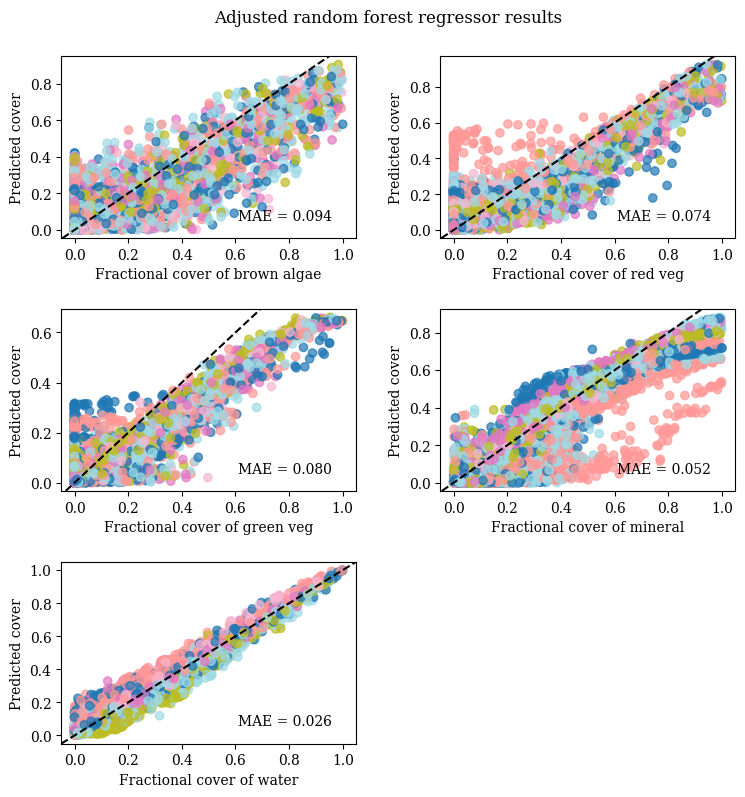

In [124]:
# Plot new data regression results
plotting_params = {
    "x_array": new_pixel_fpcs, 
    "y_array": new_overall_test_results, 
    "alpha": 0.7, #new_overall_test_results.iloc[:,-1], 
    "colour": new_endmembers.iloc[:, 3], #new_overall_test_results.iloc[:,-1], #new_endmembers.iloc[:, 4],
    "metric" : "MAE",
    "cmap" : "tab20", 
    "fig_title" : "Adjusted random forest regressor results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : new_stats,
    "line_1_1" : True,
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : False,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "reg_new_data_mineral_endmember"
}
plot_multi_result(**plotting_params)  

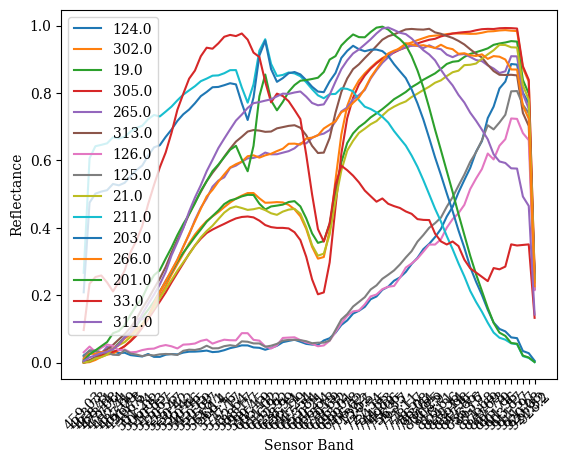

In [125]:
# Plot the endmembers of a chosen class
cleaned = [x for x in new_endmembers.iloc[:, 3].unique() if not isnan(x)]

plt.plot(data_test.loc[cleaned, data_test.columns[1] : data_test.columns[-1]].T)
plt.legend(cleaned)
plt.xticks(rotation = 45)
plt.xlabel("Sensor Band")
plt.ylabel("Reflectance")
plt.show()

In [126]:
# Invert and adjust for totality
new_adjusted_predicted = invert_predicted_values(np.array(new_overall_test_results), new_pixel_fpcs, fitted_curves)
new_area_adjusted = new_adjusted_predicted.div(new_adjusted_predicted.sum(axis = 1), axis = 0)
new_adj_stats = calc_eval_stats(new_pixel_fpcs, new_area_adjusted)

In [127]:
print(f"Inverted and Area adjusted: \n {pd.DataFrame(new_adj_stats)}\n \n")
print(f"Regression predictions : \n {pd.DataFrame(new_stats)}")

Inverted and Area adjusted: 
          R2       MSE      RMSE       MAE         MAPE
0  0.770606  0.016336  0.127812  0.087680  1947.236854
1  0.834832  0.011296  0.106281  0.068780  1022.629907
2  0.879126  0.008703  0.093288  0.060461   486.179532
3  0.798815  0.014517  0.120488  0.062779   219.350491
4  0.929296  0.006841  0.082709  0.054608   113.326525
 

Regression predictions : 
          R2       MSE      RMSE       MAE         MAPE
0  0.745671  0.018112  0.134580  0.093776  1804.605979
1  0.822458  0.012142  0.110191  0.073953  1091.199931
2  0.804381  0.014084  0.118677  0.080445   540.017023
3  0.868911  0.009459  0.097259  0.052385   383.919164
4  0.984422  0.001507  0.038822  0.026438   615.349027


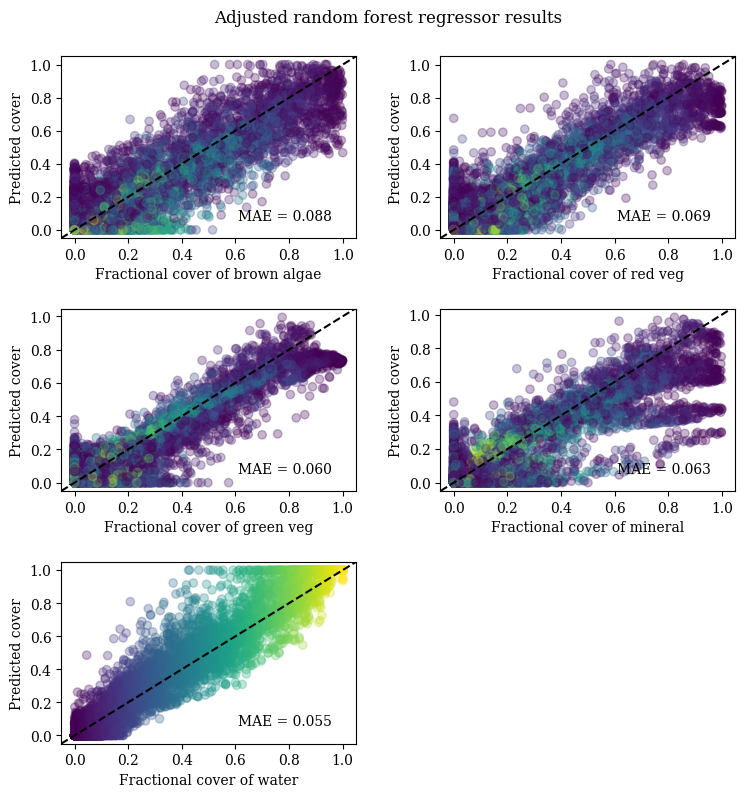

In [132]:
# Plot regression results coloured by class endmember
plotting_params = {
    "x_array": new_pixel_fpcs, 
    "y_array": new_area_adjusted, 
    "alpha": 0.3, #new_p[:,-1],
    "colour": new_pixel_fpcs.iloc[:, 4], # new_p[:,-1],
    "metric": "MAE",
    "cmap" : "viridis", 
    "fig_title" : "Adjusted random forest regressor results",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : new_adj_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : True,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "adj_reg_new_data_water_endmembers"
}
plot_multi_result(**plotting_params)  